In [1]:
# ================================
# 1️⃣ Clone the repo and set up
# ================================
!git clone https://github.com/TrustworthyMachineLearning-Lab/grokking_flatness.git
%cd grokking_flatness


fatal: destination path 'grokking_flatness' already exists and is not an empty directory.
/kaggle/working/grokking_flatness


In [2]:
# Remove strict Python/Torch pins (Colab manages versions)
!sed -i '/python==/d' requirements.txt
!sed -i '/torch/d' requirements.txt
!sed -i '/torchvision/d' requirements.txt

# Upgrade pip
!pip install --upgrade pip


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 42.0 MB/s eta 0:00:0000:01
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [12]:
# Install repo dependencies
# !pip install -r requirements.txt

!pip install tqdm


In [13]:
# Check torch + GPU
import torch
print("Torch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Enable GPU: Runtime → Change runtime type → GPU")


Torch Version: 2.9.0+cu126
CUDA Available: True
GPU: Tesla P100-PCIE-16GB


In [14]:
# ================================
# 2️⃣ Run the ResNet-18 experiment
# ================================
%cd /kaggle/working/grokking_flatness/rf_resnet18

# # Make the run script executable
# !chmod +x /content/grokking_flatness/rf_resnet18/run_script_Neural_Collapse_Suppression.sh

# # Run the experiment (this will take some time depending on GPU)
# # !sh run_script.sh
# # !bash -x run_script.sh
# !bash /content/grokking_flatness/rf_resnet18/run_script_Neural_Collapse_Suppression.sh | tee training_log.txt

/kaggle/working/grokking_flatness/rf_resnet18


In [15]:
# DATE=$(date +%m%d)

!python -u train.py \
 --learning_rate=1e-03 \
 --eta=0 \
 --training_date=$DATE \
 --mnetwork=0 \
 --model=resnet18 \
 --loss_func=CE \
 --leaky_coef=0 \
 --random_seed=42 \
 --epochs=400 \
 --num_workers=2 \
 --scheduler_stop_epoch=0 \
 --tau=2.0 \
 --weight_cap=1 \
 --cap_type=frob \
 --f_max_norm=50.0 \
 --cancel_epoch=200 \
 --help_epoch=10000 \
 --batch_size=128 \
 --weight_decay=0 \
 --use_regulation=1 \
 --phi_norm=1 \
 --use_pow=0 \
 --lambda=1e-2 \
 --loss_type1=1 \
 --loss_type2=0 \
 --loss_type2_coef=0 \
 --loss_ortho=0 \
 --ortho=0 \
 --clip_value=0 \
 --clip_norm=0 \
 --optim_type=sgd \
 --training_size=0.0 \
 > Seed42_Date${DATE}_MTresnet18_trainlog.txt 2>&1

In [16]:
# DATE=$(date +%m%d)

!python -u train.py \
 --learning_rate=1e-03 \
 --eta=0 \
 --training_date=$DATE \
 --mnetwork=0 \
 --model=resnet18 \
 --loss_func=CE \
 --leaky_coef=0 \
 --random_seed=42 \
 --epochs=400 \
 --num_workers=2 \
 --scheduler_stop_epoch=0 \
 --tau=2.0 \
 --weight_cap=1 \
 --cap_type=frob \
 --f_max_norm=50.0 \
 --cancel_epoch=10000000 \
 --help_epoch=10000 \
 --batch_size=128 \
 --weight_decay=0 \
 --use_regulation=1 \
 --phi_norm=1 \
 --use_pow=0 \
 --lambda=1e-2 \
 --loss_type1=1 \
 --loss_type2=0 \
 --loss_type2_coef=0 \
 --loss_ortho=0 \
 --ortho=0 \
 --clip_value=0 \
 --clip_norm=0 \
 --optim_type=sgd \
 --training_size=0.0 \
 > Seed42_Date${DATE}_MTresnet18_trainlog.txt 2>&1

In [17]:
from IPython.display import display
import ipywidgets as widgets
import os

# Create the upload widget
upload_widget = widgets.FileUpload(accept='.ipynb', multiple=False)
display(upload_widget)

# Function to save the uploaded notebook
def save_uploaded_notebook(widget):
    if len(widget.value) == 0:
        print("No notebook uploaded yet.")
        return None
    
    # In Kaggle, widget.value is a list of dicts
    uploaded_file = widget.value[0]  # take the first (and only) file
    filename = uploaded_file['name']
    content = uploaded_file['content']
    
    save_path = os.path.join('/kaggle/working/', filename)
    with open(save_path, 'wb') as f:
        f.write(content)
    print(f"Notebook uploaded and saved as: {save_path}")
    return save_path



FileUpload(value=(), accept='.ipynb', description='Upload')

In [18]:
# Call this after you upload
save_path = save_uploaded_notebook(upload_widget)

Notebook uploaded and saved as: /kaggle/working/relative_flatness_plot_results2.ipynb


In [19]:
# ================================
# 3️⃣ Generate figures using notebook functions
# ================================
%cd /kaggle/working/grokking_flatness/rf_resnet18

# Import plotting utilities from their notebook
# The notebook is: relative_flatness_plot_results.ipynb
# We'll run it programmatically to generate plots

!jupyter nbconvert --to notebook --execute /kaggle/working/relative_flatness_plot_results2.ipynb --output executed_plots.ipynb


/kaggle/working/grokking_flatness/rf_resnet18
/usr/local/lib/python3.12/dist-packages/mistune.py:435: SyntaxWarning: invalid escape sequence '\|'
  cells[i][c] = re.sub('\\\\\|', '|', cell)
/usr/local/lib/python3.12/dist-packages/nbconvert/filters/filter_links.py:36: SyntaxWarning: invalid escape sequence '\_'
  text = re.sub(r'_', '\_', text) # Escape underscores in display text
[NbConvertApp] Converting notebook /kaggle/working/relative_flatness_plot_results2.ipynb to notebook
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s -

In [20]:
# ================================
# 3️⃣ Load metrics and generate figures (fixed)
# ================================
import os
import numpy as np
import matplotlib.pyplot as plt
import re

# Path to ResNet-18 experiment folder
# base_path = "/content/grokking_flatness/rf_resnet18"

# # Pick the last experiment folder automatically
# exp_folder = sorted([f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))])[-1]
full_path = "/kaggle/working/grokking_flatness/rf_resnet18/Seed42_Date_MTresnet18_MRes0_EP400_CANEP200_TSIZE0.0_BSZ128_LFCE_LKCF0.0_OPTMsgd_LR0.001_WD0.0_REGR1_PHIN1_LAMBDA0.01_TAU2.0_LT11_WCAP1_CAPTfrob_FMAX50.0"
print("Using experiment folder:", full_path)

print("Experiment folder:", full_path)
print("Files inside:", os.listdir(full_path))

Using experiment folder: /kaggle/working/grokking_flatness/rf_resnet18/Seed42_Date_MTresnet18_MRes0_EP400_CANEP200_TSIZE0.0_BSZ128_LFCE_LKCF0.0_OPTMsgd_LR0.001_WD0.0_REGR1_PHIN1_LAMBDA0.01_TAU2.0_LT11_WCAP1_CAPTfrob_FMAX50.0
Experiment folder: /kaggle/working/grokking_flatness/rf_resnet18/Seed42_Date_MTresnet18_MRes0_EP400_CANEP200_TSIZE0.0_BSZ128_LFCE_LKCF0.0_OPTMsgd_LR0.001_WD0.0_REGR1_PHIN1_LAMBDA0.01_TAU2.0_LT11_WCAP1_CAPTfrob_FMAX50.0
Files inside: ['hessian_27.npy', 'cluster_value_132.npy', 'train_acc_113.npy', 'train_acc_253.npy', 'train_acc_391.npy', 'val_loss_21.npy', 'val_loss_28.npy', 'hessian_86.npy', 'hessian_second_399.npy', 'hessian_second_210.npy', 'train_acc_147.npy', 'hessian_first_114.npy', 'train_loss_222.npy', 'val_loss_285.npy', 'val_loss_275.npy', 'cluster_value_65.npy', 'train_acc_83.npy', 'val_loss_133.npy', 'sharpness_368.npy', 'train_acc_131.npy', 'val_acc_100.npy', 'train_acc_102.npy', 'sharpness_68.npy', 'train_loss_304.npy', 'train_loss_287.npy', 'var_clas

In [21]:
# ------------------------------------------------------------
# Helper to load indexed .npy files
# ------------------------------------------------------------
def load_indexed_series(prefix):
    files = [f for f in os.listdir(full_path) if f.startswith(prefix)]

    def extract_idx(name):
        return int(re.findall(r'\d+', name)[-1])

    files = sorted(files, key=extract_idx)

    values = []
    for f in files:
        arr = np.load(os.path.join(full_path, f))
        if np.isscalar(arr):
            values.append(arr)
        elif arr.size == 1:
            values.append(arr.item())
        else:
            values.append(arr)

    return np.array(values)

# Load all metrics
train_acc = load_indexed_series("train_acc_")
val_acc   = load_indexed_series("val_acc_")
sharpness = load_indexed_series("sharpness_")       # Relative Flatness
ncc       = load_indexed_series("cluster_value_")   # NCC

# Ensure arrays are same length
min_len = min(len(train_acc), len(val_acc), len(sharpness), len(ncc))
train_acc = train_acc[:min_len]
val_acc   = val_acc[:min_len]
sharpness = sharpness[:min_len]
ncc       = ncc[:min_len]

epochs = np.arange(1, min_len + 1)


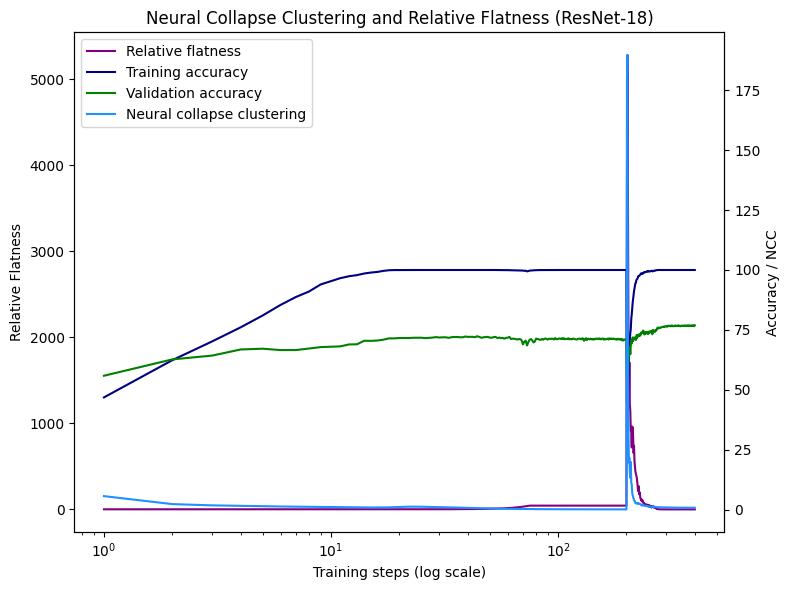

In [22]:
# ================================
# 4️⃣ FIGURE 1 — Combined Plot
# ================================
fig, ax1 = plt.subplots(figsize=(8,6))
ax1.plot(epochs, sharpness, color="purple", label="Relative flatness")
ax1.set_xscale("log")
ax1.set_xlabel("Training steps (log scale)")
ax1.set_ylabel("Relative Flatness")

ax2 = ax1.twinx()
ax2.plot(epochs, train_acc, color="navy", label="Training accuracy")
ax2.plot(epochs, val_acc, color="green", label="Validation accuracy")
ax2.plot(epochs, ncc, color="dodgerblue", label="Neural collapse clustering")
ax2.set_ylabel("Accuracy / NCC")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Neural Collapse Clustering and Relative Flatness (ResNet-18)")
plt.tight_layout()
plt.show()


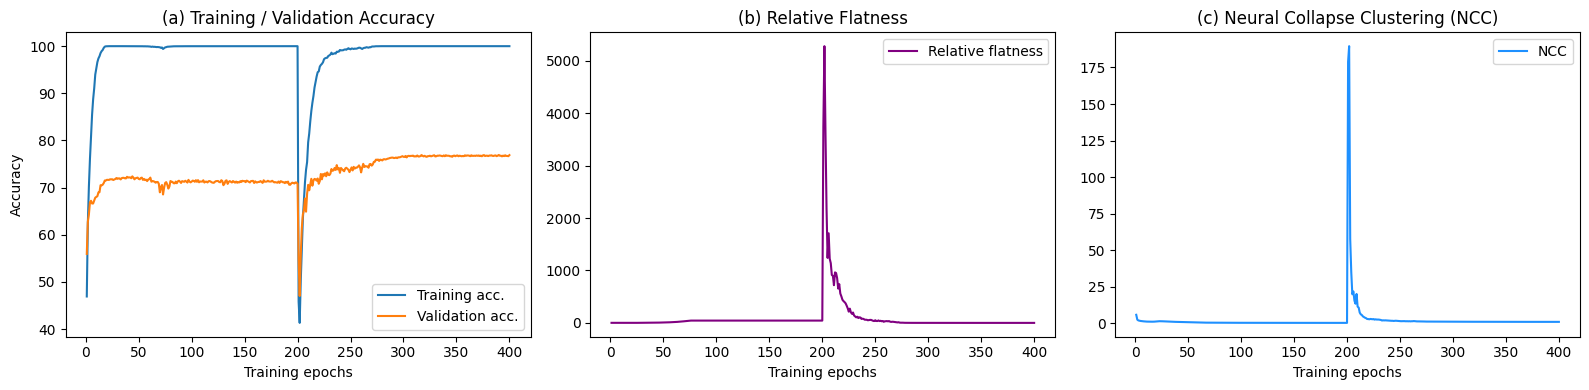

In [23]:
# ================================
# 5️⃣ FIGURE 2 — 3 Panel Layout
# ================================
fig, axes = plt.subplots(1, 3, figsize=(16,4))

# (a) Training / Validation Accuracy
axes[0].plot(epochs, train_acc, label="Training acc.")
axes[0].plot(epochs, val_acc, label="Validation acc.")
axes[0].set_title("(a) Training / Validation Accuracy")
axes[0].set_xlabel("Training epochs")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# (b) Relative Flatness
axes[1].plot(epochs, sharpness, label="Relative flatness", color="purple")
axes[1].set_title("(b) Relative Flatness")
axes[1].set_xlabel("Training epochs")
axes[1].legend()

# (c) Neural Collapse Clustering
axes[2].plot(epochs, ncc, label="NCC", color="dodgerblue")
axes[2].set_title("(c) Neural Collapse Clustering (NCC)")
axes[2].set_xlabel("Training epochs")
axes[2].legend()

plt.tight_layout()
plt.show()

In [24]:
from IPython.display import FileLink
FileLink("/kaggle/working/executed_plots.ipynb")

/kaggle/working/executed_plots.ipynb

In [24]:
plugged_path = "/kaggle/working/grokking_flatness/rf_resnet18/Seed42_Date_MTresnet18_MRes0_EP400_CANEP10000000_TSIZE0.0_BSZ128_LFCE_LKCF0.0_OPTMsgd_LR0.001_WD0.0_REGR1_PHIN1_LAMBDA0.01_TAU2.0_LT11_WCAP1_CAPTfrob_FMAX50.0"

unplugged_path = "/kaggle/working/grokking_flatness/rf_resnet18/Seed42_Date_MTresnet18_MRes0_EP400_CANEP200_TSIZE0.0_BSZ128_LFCE_LKCF0.0_OPTMsgd_LR0.001_WD0.0_REGR1_PHIN1_LAMBDA0.01_TAU2.0_LT11_WCAP1_CAPTfrob_FMAX50.0"

In [25]:
def load_indexed_series(base_path, prefix):
    files = [f for f in os.listdir(base_path) if f.startswith(prefix)]

    def extract_idx(name):
        return int(re.findall(r'\d+', name)[-1])

    files = sorted(files, key=extract_idx)

    values = []
    for f in files:
        arr = np.load(os.path.join(base_path, f))
        if np.isscalar(arr):
            values.append(arr)
        elif arr.size == 1:
            values.append(arr.item())
        else:
            values.append(arr)

    return np.array(values)

In [26]:
# Plugged
train_acc_p = load_indexed_series(plugged_path, "train_acc_")
val_acc_p   = load_indexed_series(plugged_path, "val_acc_")

# Unplugged
train_acc_u = load_indexed_series(unplugged_path, "train_acc_")
val_acc_u   = load_indexed_series(unplugged_path, "val_acc_")

In [27]:
min_len = min(len(train_acc_p), len(val_acc_p),
              len(train_acc_u), len(val_acc_u))

train_acc_p = train_acc_p[:min_len]
val_acc_p   = val_acc_p[:min_len]
train_acc_u = train_acc_u[:min_len]
val_acc_u   = val_acc_u[:min_len]

epochs = np.arange(1, min_len + 1)

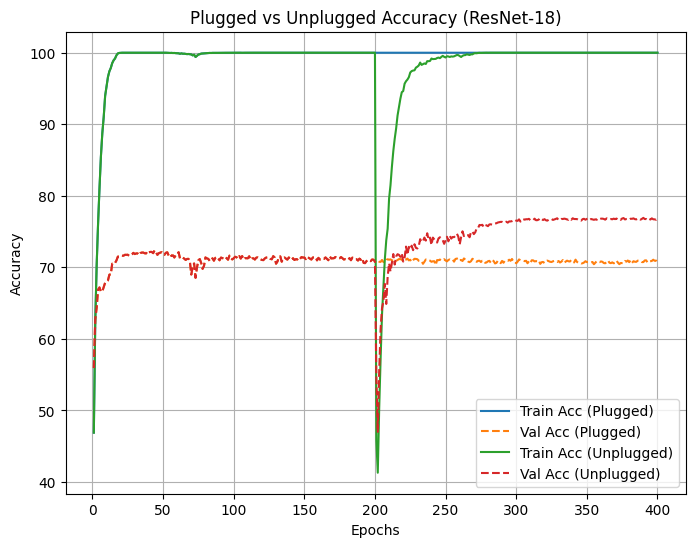

In [33]:
plt.figure(figsize=(8,6))

plt.plot(epochs, train_acc_p, label="Train Acc (Plugged)", linestyle='-')
plt.plot(epochs, val_acc_p,   label="Val Acc (Plugged)", linestyle='--')

plt.plot(epochs, train_acc_u, label="Train Acc (Unplugged)", linestyle='-')
plt.plot(epochs, val_acc_u,   label="Val Acc (Unplugged)", linestyle='--')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Plugged vs Unplugged Accuracy (ResNet-18)")
plt.legend()
plt.grid()
plt.show()

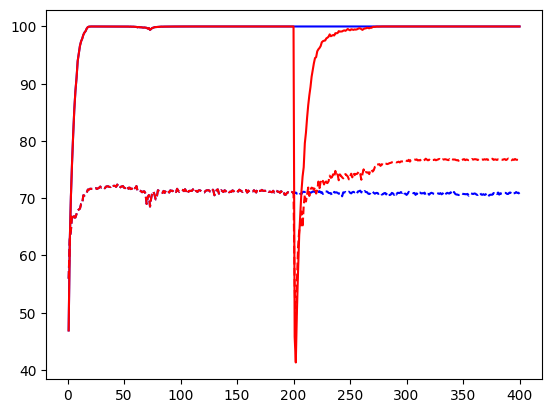

In [29]:
plt.plot(epochs, train_acc_p, color="blue", label="Train Plugged")
plt.plot(epochs, val_acc_p,   color="blue", linestyle="--", label="Val Plugged")

plt.plot(epochs, train_acc_u, color="red", label="Train Unplugged")
plt.plot(epochs, val_acc_u,   color="red", linestyle="--", label="Val Unplugged")

In [35]:
import nbformat
from nbconvert.preprocessors import ExecutePreprocessor
import base64
import os

with open("/kaggle/working/executed_plots.ipynb") as f:
    nb = nbformat.read(f, as_version=4)

img_count = 0

for cell in nb['cells']:
    if 'outputs' in cell:
        for output in cell['outputs']:
            if 'data' in output and 'image/png' in output['data']:
                img_data = base64.b64decode(output['data']['image/png'])
                with open(f"plot_{img_count}.png", "wb") as f:
                    f.write(img_data)
                img_count += 1

print(f"Extracted {img_count} plots")

Extracted 1 plots


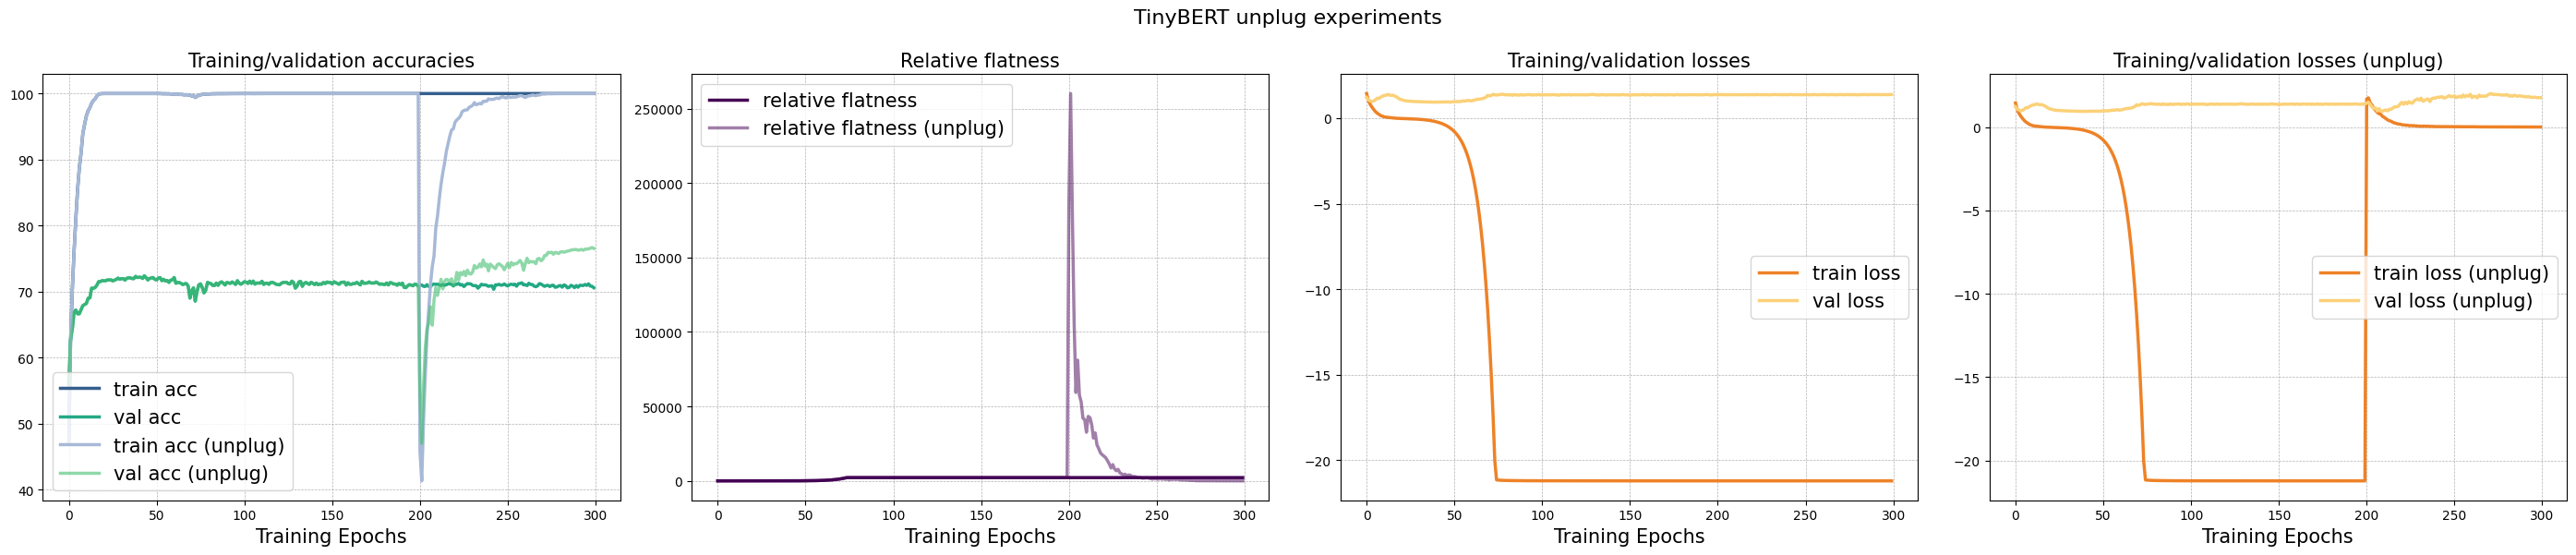

In [37]:
from IPython.display import Image, display

display(Image("/kaggle/working/grokking_flatness/rf_resnet18/plot_0.png"))